In [1]:
import os

import matplotlib.pyplot as plt

import torch
import tensorkrowch as tk

from utils import *

## Train LR model

In [2]:
cwd = os.getcwd()
data_dir = os.path.join(cwd, '..')

models_dir = os.path.join(cwd, 'results', 'models')
os.makedirs(models_dir, exist_ok=True)

model_name = 'lr'
n_classes = 2

featuresNA = ['TMB', 'Albumin', 'NLR', 'Age', 'Systemic_therapy_history',
              'CancerType1', 'CancerType2', 'CancerType3', 'CancerType4',
              'CancerType5', 'CancerType6', 'CancerType7', 'CancerType8',
              'CancerType9', 'CancerType10', 'CancerType11', 'CancerType12',
              'CancerType13', 'CancerType14', 'CancerType15', 'CancerType16']
phenoNA = 'Response'

numeric_featuresNA = ['TMB', 'Albumin', 'NLR', 'Age']

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']

In [3]:
# Load data
# ---------
scaler_type = 'standard'

dataset = ['Chowell_train']
data_train, scalers_train = load_data(data_dir,
                                      featuresNA,
                                      phenoNA,
                                      dataset,
                                      scaler_type)

dataset = ['Chowell_test']
data_test, scalers_test = load_data(data_dir,
                                    featuresNA,
                                    phenoNA,
                                    dataset,
                                    scaler_type)

In [4]:
# Train vanilla model
# -------------------
x_train = data_train[featuresNA].values
y_train = data_train[phenoNA].values

x_test = data_test[featuresNA].values
y_test = data_test[phenoNA].values

loris_van = train_lr_model('vanilla', x_train, y_train, x_test, y_test)
# save_lr(loris_van, os.path.join(models_dir, 'loris_van.pkl'))

loris_van = load_lr(os.path.join(models_dir, 'loris_van.pkl'))

*TRAINING MODEL*

Accuracy: Train: 0.69, Test: 0.72
Balanced accuracy: Train: 0.68, Test: 0.69

*Correct predicitons*
Train:
    Class 0: 486 / 682 (0.7126)
    Class 1: 182 / 282 (0.6454)
Test:
    Class 0: 288 / 388 (0.7423)
    Class 1: 82 / 127 (0.6457)



In [5]:
# Train average model
# -------------------
x_train = data_train[featuresNA].values
y_train = data_train[phenoNA].values

x_test = data_test[featuresNA].values
y_test = data_test[phenoNA].values

loris_avg = train_lr_model('average', x_train, y_train, x_test, y_test)
# save_lr(loris_van, os.path.join(models_dir, 'loris_avg.pkl'))

loris_avg = load_lr(os.path.join(models_dir, 'loris_avg.pkl'))

*TRAINING MODEL*

Accuracy: Train: 0.69, Test: 0.73
Balanced accuracy: Train: 0.68, Test: 0.69

*Correct predicitons*
Train:
    Class 0: 489 / 682 (0.7170)
    Class 1: 180 / 282 (0.6383)
Test:
    Class 0: 294 / 388 (0.7577)
    Class 1: 80 / 127 (0.6299)



## Tensorize LR

In [6]:
dataset = datasets
data_sketch, scalers_sketch = load_sketch_data(data_dir,
                                               featuresNA,
                                               phenoNA,
                                               dataset,
                                               scaler_type,
                                               n_samples=10)

x_sketch = data_sketch[featuresNA].values
y_sketch = data_sketch[phenoNA].values

print(x_sketch.shape)

(297, 21)


In [7]:
xt_train = torch.from_numpy(x_train).float()
yt_train = torch.from_numpy(y_train)

xt_test = torch.from_numpy(x_test).float()
yt_test = torch.from_numpy(y_test)

xt_sketch = torch.from_numpy(x_sketch).float()
yt_sketch = torch.from_numpy(y_sketch)

In [8]:
# Tensorize model
# ---------------
sketch_size    = 50
phys_dim       = 2
domain         = None
bond_dim       = 2
cum_percentage = 1 - 1e-2
batch_size     = 1000
device         = torch.device('cpu')
dtype          = torch.float
verbose        = False


def fn_model(data, n_bins=6):
    # Get probabilities (numpy)
    y_proba = loris_van.predict_proba(data)
    y_proba = torch.from_numpy(y_proba).float()
    
    discr_out = discretize(vector=y_proba, n_bins=n_bins)
    return discr_out.sqrt()

def embedding(data):
    return tk.embeddings.poly(data, degree=phys_dim - 1).float()


mps = tensorize(fn_model=fn_model,
                embedding=embedding,
                x_train=xt_train,
                y_train=yt_train,
                x_test=xt_test,
                y_test=yt_test,
                x_sketch=xt_sketch,
                y_sketch=yt_sketch,
                sketch_size=sketch_size,
                phys_dim=phys_dim,
                domain=domain,
                bond_dim=bond_dim,
                cum_percentage=cum_percentage,
                batch_size=batch_size,
                device=device,
                dtype=dtype,
                verbose=verbose)

*TENSORIZING MODEL*

Info: {'total_time': 0.27793073654174805, 'val_eps': tensor(0.0973)}

MSE: Sketch: 4.60e-02, Train: 0.023, Test: 2.40e-02
tensor([[0.9494, 0.3676],
        [0.3521, 0.8575],
        [0.1065, 0.9525],
        [0.2318, 0.9102],
        [0.5191, 0.8384],
        [0.5332, 0.8395],
        [0.8354, 0.6031],
        [0.4839, 0.8651],
        [0.2937, 0.9981],
        [0.6016, 0.8195]])
tensor([[0.9129, 0.4082],
        [0.4082, 0.9129],
        [0.0000, 1.0000],
        [0.0000, 1.0000],
        [0.5774, 0.8165],
        [0.4082, 0.9129],
        [0.8165, 0.5774],
        [0.4082, 0.9129],
        [0.4082, 0.9129],
        [0.5774, 0.8165]])
tensor([0, 1, 0, 1, 1, 1, 0, 1, 1, 1])

*Sketch accuracies*
Accuracy: TT: 0.61, LR: 0.66
Balanced accuracy: TT: 0.60, LR: 0.65

*Train/test TT accuracies*
Accuracy: Train: 0.68, Test: 0.71
Balanced accuracy: Train: 0.67, Test: 0.69

*Correct predicitons*
Train:
    Class 0: 468 / 682 (0.6862)
    Class 1: 184 / 282 (0.6525)
Test:
   

In [9]:
# save
# torch.save(mps.tensors, os.path.join(models_dir, 'mps.pt'))

# load
cores = torch.load(os.path.join(models_dir, 'mps.pt'))
mps = tk.models.MPSLayer(tensors=cores)
mps.trace(torch.zeros(1, xt_sketch.size(1), phys_dim))


In [10]:
# Renormalize model
# -----------------

# We renormalize the tensor network so that it represents a normalized
# distribution of all the features, instead of only giving normalized
# conditional distributions for the output feature ("Response")

# Contiuous variables have to be integrated. "discr_steps" indicates the number
# of dicretization steps used to discretize the continuous variable and perform
# numerical integration
discr_steps = int(1e5)

mps = renormalize(mps=mps,
                  phys_dim=phys_dim,
                  discr_steps=discr_steps,
                  n_classes=n_classes,
                  num_features=numeric_featuresNA,
                  x_train=xt_train,
                  y_train=yt_train,
                  x_test=xt_test,
                  y_test=yt_test)

*RENORMALIZING MODEL*

Norm: 14315.9033
Model accuracy: Train: 0.69, Test: 0.72
Model balanced accuracy: Train: 0.68, Test: 0.69
Correct predicitons
Train:
    Class 0: 478 / 682 (0.7009)
    Class 1: 185 / 282 (0.6560)
Test:
    Class 0: 288 / 388 (0.7423)
    Class 1: 81 / 127 (0.6378)



## Train NN model

In [11]:
# Train NN model
# --------------

loris_nn = train_nn_model(xt_train, yt_train, xt_test, yt_test)
# save_nn(loris_nn, os.path.join(models_dir, 'loris_nn.pkl'))

loris_nn = load_nn(xt_train.shape[1], os.path.join(models_dir, 'loris_nn.pkl'))

*TRAINING MODEL*

Accuracy: Train: 0.77, Test: 0.76
Balanced accuracy: Train: 0.69, Test: 0.66

*Correct predicitons*
Train:
    Class 0: 595 / 682 (0.8724)
    Class 1: 145 / 282 (0.5142)
Test:
    Class 0: 334 / 388 (0.8608)
    Class 1: 58 / 127 (0.4567)



## Tensorize NN

In [12]:
# Tensorize model
# ---------------
sketch_size    = 50
phys_dim       = 2
domain         = None
bond_dim       = 2
cum_percentage = 1 - 1e-2
batch_size     = 1000
device         = torch.device('cpu')
dtype          = torch.float
verbose        = False


def fn_model(data, n_bins=6):
    # Get probabilities (numpy)
    y_proba = loris_nn(data)
    y_proba = torch.cat([1 - y_proba, y_proba], dim=1)
    
    discr_out = discretize(vector=y_proba, n_bins=n_bins)
    return discr_out.sqrt()

def embedding(data):
    return tk.embeddings.poly(data, degree=phys_dim - 1).float()


mps_nn = tensorize(fn_model=fn_model,
                   embedding=embedding,
                   x_train=xt_train,
                   y_train=yt_train,
                   x_test=xt_test,
                   y_test=yt_test,
                   x_sketch=xt_sketch,
                   y_sketch=yt_sketch,
                   sketch_size=sketch_size,
                   phys_dim=phys_dim,
                   domain=domain,
                   bond_dim=bond_dim,
                   cum_percentage=cum_percentage,
                   batch_size=batch_size,
                   device=device,
                   dtype=dtype,
                   verbose=verbose)

*TENSORIZING MODEL*

Info: {'total_time': 0.21477341651916504, 'val_eps': tensor(0.4378)}

MSE: Sketch: 2.49e-01, Train: 0.2, Test: 1.74e-01
tensor([[0.8412, 0.0864],
        [0.9566, 0.0991],
        [0.9756, 0.0619],
        [0.8743, 0.2357],
        [0.6425, 0.4183],
        [0.5539, 0.6652],
        [0.7942, 0.3359],
        [1.0160, 0.0196],
        [0.2990, 0.4401],
        [0.9081, 0.0104]])
tensor([[1.0000, 0.0000],
        [1.0000, 0.0000],
        [1.0000, 0.0000],
        [1.0000, 0.0000],
        [0.0000, 1.0000],
        [0.5774, 0.8165],
        [1.0000, 0.0000],
        [1.0000, 0.0000],
        [0.0000, 1.0000],
        [1.0000, 0.0000]])
tensor([0, 0, 0, 0, 1, 1, 0, 0, 1, 1])

*Sketch accuracies*
Accuracy: TT: 0.63, LR: 0.68
Balanced accuracy: TT: 0.61, LR: 0.67

*Train/test TT accuracies*
Accuracy: Train: 0.71, Test: 0.73
Balanced accuracy: Train: 0.65, Test: 0.67

*Correct predicitons*
Train:
    Class 0: 547 / 682 (0.8021)
    Class 1: 142 / 282 (0.5035)
Test:
    C

In [13]:
# save
# torch.save(mps_nn.tensors, os.path.join(models_dir, 'mps_nn.pt'))

# load
cores = torch.load(os.path.join(models_dir, 'mps_nn.pt'))
mps_nn = tk.models.MPSLayer(tensors=cores)
mps_nn.trace(torch.zeros(1, xt_sketch.size(1), phys_dim))


In [14]:
# Renormalize model
# -----------------

# We renormalize the tensor network so that it represents a normalized
# distribution of all the features, instead of only giving normalized
# conditional distributions for the output feature ("Response")

# Contiuous variables have to be integrated. "discr_steps" indicates the number
# of dicretization steps used to discretize the continuous variable and perform
# numerical integration
discr_steps = int(1e5)

mps_nn = renormalize(mps=mps_nn,
                     phys_dim=phys_dim,
                     discr_steps=discr_steps,
                     n_classes=n_classes,
                     num_features=numeric_featuresNA,
                     x_train=xt_train,
                     y_train=yt_train,
                     x_test=xt_test,
                     y_test=yt_test)

*RENORMALIZING MODEL*

Norm: 13117.8799
Model accuracy: Train: 0.72, Test: 0.74
Model balanced accuracy: Train: 0.65, Test: 0.68
Correct predicitons
Train:
    Class 0: 549 / 682 (0.8050)
    Class 1: 142 / 282 (0.5035)
Test:
    Class 0: 314 / 388 (0.8093)
    Class 1: 69 / 127 (0.5433)



In [15]:
def lr_van_model(data):
    result = torch.from_numpy(loris_van.predict_proba(data)).float()
    return result

def lr_avg_model(data):
    result = torch.from_numpy(loris_avg.predict_proba(data)).float()
    return result

def nn_model(data):
    result = loris_nn(data)
    result = torch.cat([1 - result, result], dim=1)
    return result

def embedding(data):
    return tk.embeddings.poly(data, degree=phys_dim - 1).float()

def tt_model(data):
    result = mps(embedding(data)).pow(2)
    result = result / result.sum(dim=1, keepdim=True)
    return result

def tt_model_nn(data):
    result = mps_nn(embedding(data)).pow(2)
    result = result / result.sum(dim=1, keepdim=True)
    return result

In [16]:
lr_van_model(xt_test)

tensor([[0.2541, 0.7459],
        [0.4482, 0.5518],
        [0.5097, 0.4903],
        ...,
        [0.5680, 0.4320],
        [0.7511, 0.2489],
        [0.5113, 0.4887]])

In [17]:
lr_avg_model(xt_test)

tensor([[0.2541, 0.7459],
        [0.4482, 0.5518],
        [0.5097, 0.4903],
        ...,
        [0.5680, 0.4320],
        [0.7511, 0.2489],
        [0.5113, 0.4887]])

In [18]:
nn_model(xt_test)

tensor([[-0.6841,  1.6841],
        [-0.0457,  1.0457],
        [ 0.6590,  0.3410],
        ...,
        [ 0.4445,  0.5555],
        [ 2.5294, -1.5294],
        [ 1.3347, -0.3347]], grad_fn=<CatBackward0>)

In [19]:
tt_model(xt_test)

tensor([[0.1655, 0.8345],
        [0.4329, 0.5671],
        [0.5300, 0.4700],
        ...,
        [0.6128, 0.3872],
        [0.8569, 0.1431],
        [0.4726, 0.5274]], grad_fn=<DivBackward0>)

In [20]:
tt_model_nn(xt_test)

tensor([[0.2400, 0.7600],
        [0.7646, 0.2354],
        [0.9343, 0.0657],
        ...,
        [0.7800, 0.2200],
        [0.9576, 0.0424],
        [0.3872, 0.6128]], grad_fn=<DivBackward0>)

## Study distributions

### Examples

In [21]:
# Get conditional/marginal distribution
# -------------------------------------

# We need to specify the condition and marginal variables. The rest will be
# marginalized out. The "Response" feature can be included as condition or
# marginal

# Select features on which we condition
cond_features = ['TMB', 'Albumin']

# Create tensor with values (already scaled to [0, 1])
# for conditioned features
cond_data = [0.2, 0.9]  # Just an example

# Select features which we marginalize
marg_features = ['Systemic_therapy_history', 'Response']

# In this example, we will get the distribution 
# P('Systemic_therapy_history', 'Response' | 'TMB', 'Albumin'),
# marginalizing out the rest of the features

# The distribution will be given as a tensor with shape:
# (dim_marg_1, ..., dim_marg_n), with "dim_marg_{i}" being the dimensions of
# each marginal feature. These marginal features could be returned in a
# different order as the one specified in "marg_features". The order will
# be returned in the list "marg_feat_order"

# For continuous features, the dimension of the marginal features will be the
# specified "discr_steps"

discr_steps = int(1e5)

distr, marg_feat_order = get_distribution(
    mps=mps,
    cond_features=cond_features,
    cond_data=cond_data,
    marg_features=marg_features,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=discr_steps
)

print(marg_feat_order, distr.shape)
print(distr)
print(distr.sum())
print(marg_feat_order[1], distr.sum(dim=0))
print(marg_feat_order[0], distr.sum(dim=1))
print()

['Systemic_therapy_history', 'Response'] torch.Size([2, 2])
tensor([[0.3069, 0.2344],
        [0.2678, 0.1909]])
tensor(1.)
Response tensor([0.5747, 0.4253])
Systemic_therapy_history tensor([0.5413, 0.4587])



In [22]:
# Example 2
cond_features = ['Response']
cond_data = [1.]

marg_features = ['TMB']

discr_steps = int(1e1)  # int(1e5)

distr, marg_feat_order = get_distribution(
    mps=mps,
    cond_features=cond_features,
    cond_data=cond_data,
    marg_features=marg_features,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=discr_steps
)

print(marg_feat_order, distr.shape)
print(distr)
print(distr.sum())
print()

['TMB'] torch.Size([10])
tensor([0.0555, 0.0614, 0.0688, 0.0777, 0.0881, 0.0999, 0.1133, 0.1282, 0.1446,
        0.1624])
tensor(1.)



In [23]:
# Example 3
cond_features = ['Systemic_therapy_history']
cond_data = [0.]

marg_features = ['Response']

discr_steps = int(1e5)

distr, marg_feat_order = get_distribution(
    mps=mps,
    cond_features=cond_features,
    cond_data=cond_data,
    marg_features=marg_features,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=discr_steps
)

print(marg_feat_order, distr.shape)
print(distr)
print(distr.sum())
print()

['Response'] torch.Size([2])
tensor([0.5903, 0.4097])
tensor(1.0000)



In [24]:
# Example 4
cond_features = []
cond_data = []

marg_features = ['Response', 'Albumin']

discr_steps = int(1e1)  # int(1e5)

distr, marg_feat_order = get_distribution(
    mps=mps,
    cond_features=cond_features,
    cond_data=cond_data,
    marg_features=marg_features,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=discr_steps
)

print(marg_feat_order, distr.shape)
print(distr / distr.sum(dim=1, keepdim=True))
print()

['Albumin', 'Response'] torch.Size([2, 2])
tensor([[0.7300, 0.2700],
        [0.4680, 0.5320]])



### Feature Importance

In [25]:
# TMB: We know TMB above 27 indicates better response

low = marginal_prediction(
    mps=mps,
    cond_feature='TMB',
    cond_data=5,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

mid = marginal_prediction(
    mps=mps,
    cond_feature='TMB',
    cond_data=27,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

high = marginal_prediction(
    mps=mps,
    cond_feature='TMB',
    cond_data=50,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

print('TMB Example:')
print(f'TT Score: {low:.4f}, {mid:.4f}, {high:.4f}')
print()

TMB Example:
TT Score: 0.2402, 0.4199, 0.6234



In [26]:
# Age: We know Age has a small impact on response

low = marginal_prediction(
    mps=mps,
    cond_feature='Age',
    cond_data=30,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

mid = marginal_prediction(
    mps=mps,
    cond_feature='Age',
    cond_data=50,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

high = marginal_prediction(
    mps=mps,
    cond_feature='Age',
    cond_data=80,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

print('Age Example:')
print(f'TT Score: {low:.4f}, {mid:.4f}, {high:.4f}')
print()

Age Example:
TT Score: 0.4248, 0.4473, 0.4828



In [27]:
# PSTH: We know that history of treatment lowers effectiveness of treatment

low = marginal_prediction(
    mps=mps,
    cond_feature='Systemic_therapy_history',
    cond_data=0,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

high = marginal_prediction(
    mps=mps,
    cond_feature='Systemic_therapy_history',
    cond_data=1,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

print('PSTH Example:')
print(f'TT Score: {low:.4f}, {high:.4f}')
print()

PSTH Example:
TT Score: 0.5451, 0.3461



### Individual Patient Predictions

In [28]:
# Patient 1 -> Cancer: Melanoma, PSTH: No, Age: 64, Albumin: 4.8
#              NLR: 4.7, PD-L1: –, TMB: 21

patient = [21, 4.8, 4.7, 64, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]

lr_van_result = patient_prediction(lr_van_model, patient, featuresNA, scalers_train)
lr_avg_result = patient_prediction(lr_avg_model, patient, featuresNA, scalers_train)
tt_result = patient_prediction(tt_model, patient, featuresNA, scalers_train)

print('Patient 1:')
print(f'LORIS (vanilla) score: {lr_van_result:.4f}\n'
      f'LORIS (average) score: {lr_avg_result:.4f}\n'
      f'TT Score: {tt_result:.4f}')
print()

Patient 1:
LORIS (vanilla) score: 0.7942
LORIS (average) score: 0.7942
TT Score: 0.8961



In [29]:
# Patient 2 -> Cancer: NSCLC, PSTH: Yes, Age: 50, Albumin: 3.5,
#              NLR: 6.3, PD-L1: –, TMB: 8

patient = [8, 3.5, 6.3, 50, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]

lr_van_result = patient_prediction(lr_van_model, patient, featuresNA, scalers_train)
lr_avg_result = patient_prediction(lr_avg_model, patient, featuresNA, scalers_train)
tt_result = patient_prediction(tt_model, patient, featuresNA, scalers_train)

print('Patient 2:')
print(f'LORIS (vanilla) score: {lr_van_result:.4f}\n'
      f'LORIS (average) score: {lr_avg_result:.4f}\n'
      f'TT Score: {tt_result:.4f}')
print()

Patient 2:
LORIS (vanilla) score: 0.3138
LORIS (average) score: 0.3138
TT Score: 0.2450



In [30]:
# Patient 3 -> Cancer: Breast, PSTH: No,, Age: 42, Albumin: 4.6,
#              NLR: 2.3, PD-L1: –, TMB: 5

patient = [5, 4.6, 2.3, 42, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

lr_van_result = patient_prediction(lr_van_model, patient, featuresNA, scalers_train)
lr_avg_result = patient_prediction(lr_avg_model, patient, featuresNA, scalers_train)
tt_result = patient_prediction(tt_model, patient, featuresNA, scalers_train)

print('Patient 3:')
print(f'LORIS (vanilla) score: {lr_van_result:.4f}\n'
      f'LORIS (average) score: {lr_avg_result:.4f}\n'
      f'TT Score: {tt_result:.4f}')
print()


Patient 3:
LORIS (vanilla) score: 0.5794
LORIS (average) score: 0.5794
TT Score: 0.5996



### Feature sensitivity LR vs TT

In [31]:
# plt.rc('font', family='serif', serif='Computer Modern', size=16)
# plt.rc('text', usetex=True)

plt.rc('font', family='serif', serif='Times', size=16)
plt.rc('text', usetex=True)

# Font sizes
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14   # Title font size
plt.rcParams['axes.labelsize'] = 12   # Axis label font size
plt.rcParams['xtick.labelsize'] = 10  # X-axis tick label font size
plt.rcParams['ytick.labelsize'] = 10  # Y-axis tick label font size
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['legend.title_fontsize'] = 10

# Lines
plt.rcParams['axes.linewidth'] = 0.5  # Default is usually 1.0

# Ticks
plt.rcParams['xtick.major.width'] = 0.5   # Width of major ticks on X-axis
plt.rcParams['ytick.major.width'] = 0.5   # Width of major ticks on Y-axis
plt.rcParams['xtick.minor.width'] = 0.4   # Width of minor ticks on X-axis
plt.rcParams['ytick.minor.width'] = 0.4   # Width of minor ticks on Y-axis

plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4
plt.rcParams['xtick.minor.size'] = 2
plt.rcParams['ytick.minor.size'] = 2


# Replace label just for plotting
plot_labels = {
    'TMB': 'TMB',
    'Albumin': 'Albumin',
    'NLR': 'NLR',
    'Age': 'Age',
    'Systemic_therapy_history': 'PSTH',
    'CancerType1': 'Bladder',  # cancer
    'CancerType2': 'Breast',  # cancer
    'CancerType3': 'Colorectal',  # cancer
    'CancerType4': 'Endometrial',  # cancer
    'CancerType5': 'Esophageal',  # cancer
    'CancerType6': 'Gastric',  # cancer
    'CancerType7': 'Head and Neck',  # cancer
    'CancerType8': 'Hepatobiliary',  # cancer
    'CancerType9': 'Melanoma',
    'CancerType10': 'Mesothelioma',
    'CancerType11': 'Non-small cell lung',  # cancer
    'CancerType12': 'Ovarian',  # cancer
    'CancerType13': 'Pancreatic',  # cancer
    'CancerType14': 'Renal',  # cancer
    'CancerType15': 'Sarcoma',
    'CancerType16': 'Small cell lung'  # cancer
}

figures_dir = os.path.join(cwd, 'figures')
os.makedirs(figures_dir, exist_ok=True)

In [32]:
# Collect sensitivity scores
lr_van_scores = []
tt_scores = []
tt_nn_scores = []
for feat in featuresNA:
    lr_van_scores.append(feature_sensitivity_cond(feat, lr_van_model, xt_train,
                                                  featuresNA, scalers_train))
    tt_scores.append(feature_sensitivity_marg(feature=feat,
                                              mps=mps,
                                              in_features=featuresNA,
                                              out_feature=phenoNA,
                                              num_features=numeric_featuresNA,
                                              n_classes=n_classes,
                                              phys_dim=phys_dim,
                                              x_train=xt_train,
                                              discr_steps=int(1e5),
                                              scalers_dict=scalers_train))
    tt_nn_scores.append(feature_sensitivity_marg(feature=feat,
                                                 mps=mps_nn,
                                                 in_features=featuresNA,
                                                 out_feature=phenoNA,
                                                 num_features=numeric_featuresNA,
                                                 n_classes=n_classes,
                                                 phys_dim=phys_dim,
                                                 x_train=xt_train,
                                                 discr_steps=int(1e5),
                                                 scalers_dict=scalers_train))

lr_van_scores = torch.stack(lr_van_scores, dim=0)
lr_van_scores = lr_van_scores / lr_van_scores.abs().max()

tt_scores = torch.tensor(tt_scores)
tt_scores = tt_scores / tt_scores.abs().max()

tt_nn_scores = torch.tensor(tt_nn_scores)
tt_nn_scores = tt_nn_scores / tt_nn_scores.abs().max()

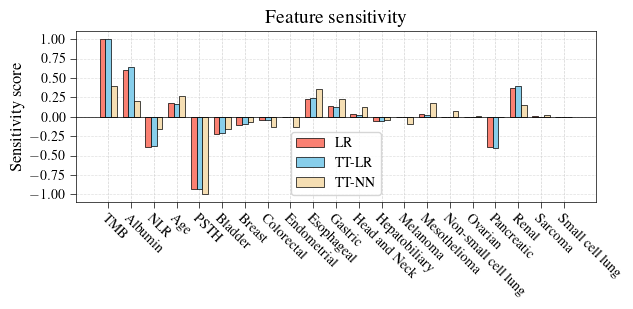

In [33]:
# Bar plot setup
x = torch.arange(len(featuresNA)) * 2  # label locations
width = 0.5  # width of the bars

fig, ax = plt.subplots(figsize=(6.5, 3.25))
bars1 = ax.bar(x - width, lr_van_scores, width, 
               label='LR', color='salmon',
               edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, tt_scores, width, 
               label='TT-LR', color='skyblue',
               edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width, tt_nn_scores, width, 
               label='TT-NN', color='wheat',
               edgecolor='black', linewidth=0.5)


# Axes settings
# ax.set_xlabel('Feature')
ax.set_ylabel('Sensitivity score')
ax.set_title('Feature sensitivity')
ax.set_xticks(x)
ax.set_xticklabels([plot_labels[feat] for feat in featuresNA],
                   rotation=-45, ha='left', rotation_mode='anchor')
ax.legend(loc='lower center')

# Horizontal line at y=0
ax.axhline(0, color='black', linewidth=0.5)

# Vertical lines at each x-tick
for xpos in x:
    ax.axvline(x=xpos, color='lightgrey',
               linestyle='--', linewidth=0.5, alpha=1, zorder=-1)

# Y-ticks every 0.1
ymin, ymax = ax.get_ylim()
# yticks = np.arange(round(ymin,1), round(ymax+0.1,1), 0.3)
yticks = np.arange(-1, 1.25, 0.25)
ax.set_yticks(np.arange(-1, 1.25, 0.25))
ax.set_ylim(-1.1, 1.1)

# Horizontal grey lines at each y-tick
for y in yticks:
    ax.axhline(y=y, color='lightgrey',
               linestyle='--', linewidth=0.5, alpha=0.7, zorder=-1)

plt.tight_layout()
# plt.savefig(os.path.join(figures_dir, 'feat_sensitivity.pdf'),
#             bbox_inches='tight')
plt.show()

### Feature sensitivity by CancerType

In [34]:
# plt.rc('font', family='serif', serif='Computer Modern', size=16)
# plt.rc('text', usetex=True)

plt.rc('font', family='serif', serif='Times', size=16)
plt.rc('text', usetex=True)

# Font sizes
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14   # Title font size
plt.rcParams['axes.labelsize'] = 12   # Axis label font size
plt.rcParams['xtick.labelsize'] = 10  # X-axis tick label font size
plt.rcParams['ytick.labelsize'] = 10  # Y-axis tick label font size
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['legend.title_fontsize'] = 10

# Lines
plt.rcParams['axes.linewidth'] = 0.5  # Default is usually 1.0

# Ticks
plt.rcParams['xtick.major.width'] = 0.5   # Width of major ticks on X-axis
plt.rcParams['ytick.major.width'] = 0.5   # Width of major ticks on Y-axis
plt.rcParams['xtick.minor.width'] = 0.4   # Width of minor ticks on X-axis
plt.rcParams['ytick.minor.width'] = 0.4   # Width of minor ticks on Y-axis

plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4
plt.rcParams['xtick.minor.size'] = 2
plt.rcParams['ytick.minor.size'] = 2


# Replace label just for plotting
plot_labels = {
    'TMB': 'TMB',
    'Albumin': 'Albumin',
    'NLR': 'NLR',
    'Age': 'Age',
    'Systemic_therapy_history': 'PSTH',
    'CancerType1': 'Bladder',  # cancer
    'CancerType2': 'Breast',  # cancer
    'CancerType3': 'Colorectal',  # cancer
    'CancerType4': 'Endometrial',  # cancer
    'CancerType5': 'Esophageal',  # cancer
    'CancerType6': 'Gastric',  # cancer
    'CancerType7': 'Head and Neck',  # cancer
    'CancerType8': 'Hepatobiliary',  # cancer
    'CancerType9': 'Melanoma',
    'CancerType10': 'Mesothelioma',
    'CancerType11': 'Non-small cell lung',  # cancer
    'CancerType12': 'Ovarian',  # cancer
    'CancerType13': 'Pancreatic',  # cancer
    'CancerType14': 'Renal',  # cancer
    'CancerType15': 'Sarcoma',
    'CancerType16': 'Small cell lung'  # cancer
}

figures_dir = os.path.join(cwd, 'figures')
os.makedirs(figures_dir, exist_ok=True)

In [35]:
aux_featuresNA = ['TMB', 'Albumin', 'NLR', 'Age', 'Systemic_therapy_history']

cancer_features = ['CancerType1', 'CancerType2', 'CancerType3', 'CancerType4',
                   'CancerType5', 'CancerType6', 'CancerType7', 'CancerType8',
                   'CancerType9', 'CancerType10', 'CancerType11', 'CancerType12',
                   'CancerType13', 'CancerType14', 'CancerType15', 'CancerType16']

mps.reset()
mps.unset_data_nodes()

scores_by_cancer = []
train_baccs = []
for cancer_idx in [2, 3, 4, 12]:  #range(16)
    # print(cancer_idx)
    cancer_scores = []
    
    # print(feat)
    aux_mps, aux_xt_train, aux_yt_train, train_bal_acc = get_cancertype_mps(
        mps, phys_dim, cancer_idx, xt_train, yt_train, scalers_train)
    train_baccs.append(train_bal_acc)
    
    # print(aux_mps.tensors)
    
    @torch.no_grad()
    def aux_tt_model(data):
        result = aux_mps(embedding(data)).pow(2)
        result = result / result.sum(dim=1, keepdim=True)
        return result
        
    for feat in aux_featuresNA:
        # print(feat)
        cancer_scores.append(feature_sensitivity_marg(feature=feat,
                                                      mps=aux_mps,
                                                      in_features=aux_featuresNA,
                                                      out_feature=phenoNA,
                                                      num_features=numeric_featuresNA,
                                                      n_classes=n_classes,
                                                      phys_dim=phys_dim,
                                                      x_train=aux_xt_train,
                                                      discr_steps=int(1e5),
                                                      scalers_dict=scalers_train))
    
    cancer_scores = torch.tensor(cancer_scores)
    # cancer_scores = cancer_scores / cancer_scores.abs().max()
    
    # print(cancer_scores)
    scores_by_cancer.append(cancer_scores)
    # print()
    # print()

Model accuracy: Train: 0.86
Model balanced accuracy: Train: 0.86
Correct predicitons
Train:
    Class 0: 18 / 21 (0.8571)
    Class 1: 6 / 7 (0.8571)

Model accuracy: Train: 0.78
Model balanced accuracy: Train: 0.71
Correct predicitons
Train:
    Class 0: 17 / 20 (0.8500)
    Class 1: 4 / 7 (0.5714)

Model accuracy: Train: 0.58
Model balanced accuracy: Train: 0.63
Correct predicitons
Train:
    Class 0: 5 / 14 (0.3571)
    Class 1: 9 / 10 (0.9000)

Model accuracy: Train: 1.00
Model balanced accuracy: Train: 1.00
Correct predicitons
Train:
    Class 0: 15 / 15 (1.0000)
    Class 1: 0 / 0 (nan)



/home/jose/anaconda3/envs/obfuscation/lib/python3.11/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [36]:
scores_by_cancer

[tensor([ 0.1151,  0.0714, -0.0454,  0.0208, -0.1124]),
 tensor([ 0.1293,  0.0643, -0.0463,  0.0218, -0.1262]),
 tensor([ 0.1220,  0.0511, -0.0430,  0.0198, -0.1276]),
 tensor([ 0.0098,  0.0032,  0.0009, -0.0036,  0.0131])]

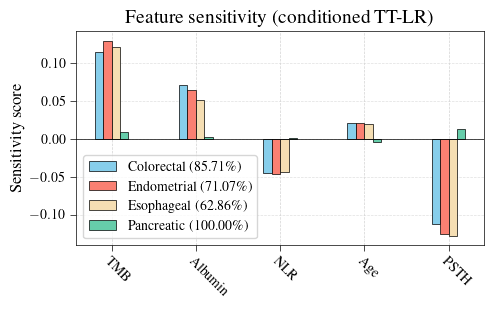

In [ ]:
fig, ax = plt.subplots(figsize=(5.1, 3.25))
colors = ['skyblue', 'salmon', 'wheat', 'mediumaquamarine']


for i, cancer_idx in enumerate([2, 3, 4, 12]):
    # Bar plot setup
    x = torch.arange(len(aux_featuresNA)) * 2  # label locations
    width = 0.2  # width of the bars
    
    bars = ax.bar(x + (-3/2 + i)*width, scores_by_cancer[i], width, 
                  label=f'{list(plot_labels.values())[cancer_idx + 5]} '
                  f'({train_baccs[i] * 100:.2f}\%)',
                  color=colors[i],
                  edgecolor='black',
                  linewidth=0.5)

# Axes settings
# ax.set_xlabel('Feature')
ax.set_ylabel('Sensitivity score')
ax.set_title(f'Feature sensitivity (conditioned TT-LR)')
ax.set_xticks(x)
ax.set_xticklabels([plot_labels[feat] for feat in aux_featuresNA],
                   rotation=-45, ha='left', rotation_mode='anchor')
ax.legend(loc='lower left')

# Horizontal line at y=0
ax.axhline(0, color='black', linewidth=0.5)

# Vertical lines at each x-tick
for xpos in x:
    ax.axvline(x=xpos, color='lightgrey',
               linestyle='--', linewidth=0.5, alpha=1, zorder=-1)

# Y-ticks every 0.1
ymin, ymax = ax.get_ylim()
# yticks = np.arange(round(ymin,1), round(ymax*1.1,1), 0.05)
yticks = np.arange(-0.1, 0.15, 0.05)
ax.set_yticks(yticks)
# ax.set_ylim(-1.1, 1.1)

# Horizontal grey lines at each y-tick
for y in yticks:
    ax.axhline(y=y, color='lightgrey',
               linestyle='--', linewidth=0.5, alpha=0.7, zorder=-1)

plt.tight_layout()
# plt.savefig(os.path.join(figures_dir, 'feat_sensitivity_cancertype.pdf'),
#             bbox_inches='tight')
plt.show()

## Monotonic plots

In [38]:
# plt.rc('font', family='serif', serif='Computer Modern', size=16)
# plt.rc('text', usetex=True)

plt.rc('font', family='serif', serif='Times', size=16)
plt.rc('text', usetex=True)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 16,
    "text.latex.preamble": r"""
        \usepackage{times}     % Times for text
        \usepackage{newtxtext} % safer Times text
        \usepackage{lmodern}   % ensure CM is available
    """
})

# Font sizes
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14   # Title font size
plt.rcParams['axes.labelsize'] = 12   # Axis label font size
plt.rcParams['xtick.labelsize'] = 10  # X-axis tick label font size
plt.rcParams['ytick.labelsize'] = 10  # Y-axis tick label font size
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['legend.title_fontsize'] = 10

# Lines
plt.rcParams['axes.linewidth'] = 0.5  # Default is usually 1.0

# Ticks
plt.rcParams['xtick.major.width'] = 0.5   # Width of major ticks on X-axis
plt.rcParams['ytick.major.width'] = 0.5   # Width of major ticks on Y-axis
plt.rcParams['xtick.minor.width'] = 0.4   # Width of minor ticks on X-axis
plt.rcParams['ytick.minor.width'] = 0.4   # Width of minor ticks on Y-axis

plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4
plt.rcParams['xtick.minor.size'] = 2
plt.rcParams['ytick.minor.size'] = 2


figures_dir = os.path.join(cwd, 'figures')
os.makedirs(figures_dir, exist_ok=True)

In [39]:
# Load data
# ---------
featuresNA = ['TMB', 'Albumin', 'NLR', 'Age', 'Systemic_therapy_history',
              'CancerType1', 'CancerType2', 'CancerType3', 'CancerType4',
              'CancerType5', 'CancerType6', 'CancerType7', 'CancerType8',
              'CancerType9', 'CancerType10', 'CancerType11', 'CancerType12',
              'CancerType13', 'CancerType14', 'CancerType15', 'CancerType16']
phenoNA = 'Response'

numeric_featuresNA = ['TMB', 'Albumin', 'NLR', 'Age']

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']

# scaler_type = 'minmax'
scaler_type = 'standard'

dataset = datasets #['Chowell_train'] # 'MSK1', 'MSK2'
data_train, scalers_train = load_data(data_dir,
                                      featuresNA,
                                      phenoNA,
                                      dataset,
                                      scaler_type)

x_train = data_train[featuresNA].values
y_train = data_train[phenoNA].values

xt_train = torch.from_numpy(x_train).float()
yt_train = torch.from_numpy(y_train)

In [40]:
# Tensorize model
# ---------------
sketch_size    = 50
phys_dim       = 2
domain         = None
bond_dim       = 2
cum_percentage = 1 - 1e-2
batch_size     = 1000
device         = torch.device('cpu')
dtype          = torch.float
verbose        = False


def fn_model(data, n_bins=20):
    # Get probabilities (numpy)
    y_proba = loris_van.predict_proba(data)
    y_proba = torch.from_numpy(y_proba).float()
    
    discr_out = discretize(vector=y_proba, n_bins=n_bins)
    return discr_out.sqrt()

def embedding(data):
    return tk.embeddings.poly(data, degree=phys_dim - 1).float()


mps2 = tensorize(fn_model=fn_model,
                 embedding=embedding,
                 x_train=xt_train,
                 y_train=yt_train,
                 x_test=xt_test,
                 y_test=yt_test,
                 x_sketch=xt_sketch,
                 y_sketch=yt_sketch,
                 sketch_size=sketch_size,
                 phys_dim=phys_dim,
                 domain=domain,
                 bond_dim=bond_dim,
                 cum_percentage=cum_percentage,
                 batch_size=batch_size,
                 device=device,
                 dtype=dtype,
                 verbose=verbose)

*TENSORIZING MODEL*

Info: {'total_time': 0.18776679039001465, 'val_eps': tensor(0.0326)}

MSE: Sketch: 5.15e-02, Train: 0.012, Test: 1.18e-02
tensor([[0.7363, 0.6774],
        [0.2578, 0.9606],
        [0.3757, 0.9471],
        [1.0127, 0.0813],
        [0.4261, 0.8986],
        [0.9696, 0.2737],
        [0.7540, 0.6592],
        [0.8508, 0.5349],
        [0.7979, 0.6194],
        [0.7820, 0.6299]])
tensor([[0.7416, 0.6708],
        [0.3162, 0.9487],
        [0.3873, 0.9220],
        [1.0000, 0.0000],
        [0.3873, 0.9220],
        [0.9487, 0.3162],
        [0.7746, 0.6325],
        [0.8660, 0.5000],
        [0.8062, 0.5916],
        [0.8062, 0.5916]])
tensor([0, 1, 1, 0, 1, 0, 0, 0, 0, 0])

*Sketch accuracies*
Accuracy: TT: 0.64, LR: 0.66
Balanced accuracy: TT: 0.63, LR: 0.65

*Train/test TT accuracies*
Accuracy: Train: 0.67, Test: 0.70
Balanced accuracy: Train: 0.65, Test: 0.68

*Correct predicitons*
Train:
    Class 0: 1401 / 2048 (0.6841)
    Class 1: 509 / 821 (0.6200)
Test:
 

In [41]:
# save
# torch.save(mps2.tensors, os.path.join(models_dir, 'mps2.pt'))

# load
cores2 = torch.load(os.path.join(models_dir, 'mps2.pt'))
mps2 = tk.models.MPSLayer(tensors=cores2)
mps2.trace(torch.zeros(1, xt_sketch.size(1), phys_dim))

In [42]:
def embedding(data):
    return tk.embeddings.poly(data, degree=phys_dim - 1).float()

def tt_model2(data):
    result = mps2(embedding(data)).pow(2)
    result = result / result.sum(dim=1, keepdim=True)
    return result

0.25, 0.71
0.16, 0.77
0.22, 0.70


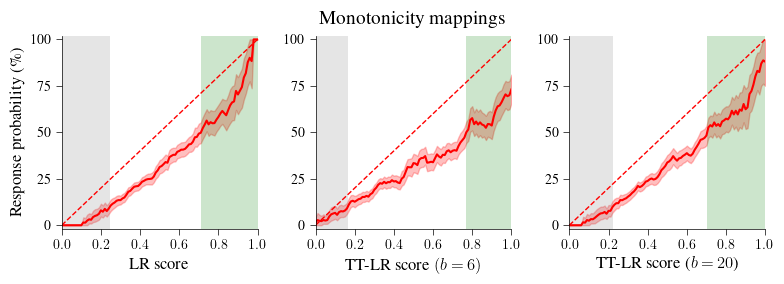

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(8, 3.1))

ax[0], x_gray, x_green = response_curve(lr_van_model,
                                        xt_train,
                                        yt_train,
                                        'LR score',
                                        ax[0])
print(f'{x_gray:.2f}, {x_green:.2f}')

ax[1], x_gray, x_green = response_curve(tt_model,
                                        xt_train,
                                        yt_train,
                                        r'TT-LR score \fontfamily{cmr}\selectfont ($b=6$)',
                                        ax[1])
print(f'{x_gray:.2f}, {x_green:.2f}')

ax[2], x_gray, x_green = response_curve(tt_model2,
                                        xt_train,
                                        yt_train,
                                        r'TT-LR score ($b=20$)',
                                        ax[2])
print(f'{x_gray:.2f}, {x_green:.2f}')


ax[0].set_ylabel('Response probability (\%)')

fig.suptitle('Monotonicity mappings', x=0.525, y=0.91, fontsize=14)


plt.tight_layout()
# plt.savefig(os.path.join(figures_dir, 'monotonicity.pdf'),
#             bbox_inches='tight')
plt.show()